# YouTube Comment Intelligence v7 — Q1-Oriented Production Notebook

Notebook ini memperbaiki v6 agar analisis tidak berhenti pada **positive / negative / neutral**.  
Output yang ditargetkan untuk website/API:

- `sentiment`: negative / neutral / positive
- `primary_issue`: isu utama yang dibahas
- `stance`: posisi sikap komentar
- `action_intent`: kecenderungan tindakan/respons publik
- `topic_id`: tema organik dari topic modeling
- visual ZIP
- `BEST_MODEL_LATEST.joblib`
- `dashboard_summary_latest.json`
- `taxonomy_config_latest.json`
- runtime backend ringan

Catatan penting: jika belum ada `labeled_comments.csv`, benchmark memakai pseudo-label BERT dan **belum boleh diklaim sebagai evaluasi ilmiah final**.

In [1]:
import sys, subprocess, importlib.util

def package_available(name):
    return importlib.util.find_spec(name) is not None

def pip_install(packages):
    if isinstance(packages, str):
        packages = [packages]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)

for import_name, packages in {
    "transformers": ["transformers", "accelerate", "sentencepiece"],
    "wordcloud": ["wordcloud"],
}.items():
    if not package_available(import_name):
        print("Installing:", packages)
        pip_install(packages)

print("Dependencies ready.")

Dependencies ready.


In [2]:
# ============================================================
# 0. SETUP, GOOGLE DRIVE MOUNT, AND PROJECT PATHS
# ============================================================
import os, re, json, html, random, shutil, warnings, sys, subprocess, importlib.util
from pathlib import Path
from datetime import datetime

# Mount Google Drive BEFORE creating /content/drive/MyDrive folders.
IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
else:
    print('Not running inside Google Colab. Drive mount skipped.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.decomposition import NMF

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')

# Main Drive folder requested by user.
DRIVE_ROOT = Path('/content/drive/MyDrive/sentimenuntoldstory')
RAW_DIR = DRIVE_ROOT / 'raw'
OUTPUT_DIR = DRIVE_ROOT / 'outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'
MODELS_DIR = OUTPUT_DIR / 'models'
REPORTS_DIR = OUTPUT_DIR / 'reports'
ZIPS_DIR = OUTPUT_DIR / 'zips'
RUNTIME_DIR = OUTPUT_DIR / 'runtime'

for d in [DRIVE_ROOT, RAW_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR, REPORTS_DIR, ZIPS_DIR, RUNTIME_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('RUN_ID:', RUN_ID)
print('DRIVE_ROOT:', DRIVE_ROOT)
print('RAW_DIR:', RAW_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

# Sanity check: warn if Drive path is empty.
try:
    root_items = list(DRIVE_ROOT.iterdir())
    print('Project folder items:', [p.name for p in root_items[:20]])
except Exception as e:
    print('Could not list project folder:', repr(e))

Mounted at /content/drive
RUN_ID: 20260616_095359
DRIVE_ROOT: /content/drive/MyDrive/sentimenuntoldstory
RAW_DIR: /content/drive/MyDrive/sentimenuntoldstory/raw
OUTPUT_DIR: /content/drive/MyDrive/sentimenuntoldstory/outputs
Project folder items: ['raw', 'outputs']


In [3]:
def save_fig(name, dpi=180):
    path = FIGURES_DIR / f"{name}_{RUN_ID}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print("Saved:", path)
    return path

def save_json(obj, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
    print("Saved:", path)
    return path

def to_count_dict(series, top_n=None):
    counts = series.fillna("unknown").astype(str).value_counts()
    if top_n:
        counts = counts.head(top_n)
    return {str(k): int(v) for k, v in counts.items()}

def to_percent_dict(series):
    counts = series.fillna("unknown").astype(str).value_counts(normalize=True) * 100
    return {str(k): round(float(v), 2) for k, v in counts.items()}

In [4]:
# ============================================================
# 1. ROBUST DATA LOADER
# This cell fixes FileNotFoundError caused by different CSV names/locations.
# It will:
# - search raw/ and project root recursively,
# - accept combined_all_comments.csv or combined_all_comments(1).csv,
# - merge part_1_all_comments + part_2_all_comments if combined file is missing,
# - optionally upload CSV manually in Colab if no file is found.
# ============================================================
from pathlib import Path
import pandas as pd
import shutil

# Priority patterns. The first valid file wins.
MAIN_PATTERNS = [
    'combined_all_comments.csv',
    'combined_all_comments*.csv',
    'combined_raw_comments.csv',
    'combined_raw_comments*.csv',
    'combined_top_level_comments.csv',
    'combined_top_level_comments*.csv',
]

PART_PATTERNS = [
    ('part_1_all_comments*.csv', 'part_2_all_comments*.csv'),
    ('raw_comments_part_1*.csv', 'raw_comments_part_2*.csv'),
]

SEARCH_DIRS = [RAW_DIR, DRIVE_ROOT, Path('/content')]
if Path('/mnt/data').exists():
    SEARCH_DIRS.append(Path('/mnt/data'))


def safe_read_csv(path, nrows=None):
    """Read CSV robustly. Falls back to common encodings if needed."""
    for enc in ['utf-8', 'utf-8-sig', 'latin1']:
        try:
            return pd.read_csv(path, encoding=enc, nrows=nrows)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, nrows=nrows)


def csv_has_comment_text(path):
    try:
        cols = list(safe_read_csv(path, nrows=3).columns)
        lower_cols = [str(c).lower() for c in cols]
        return any(c in lower_cols for c in ['comment_text', 'text', 'clean_text', 'clean_text_model'])
    except Exception:
        return False


def list_csvs_for_debug():
    print('\nCSV files detected:')
    found = []
    for folder in SEARCH_DIRS:
        if not folder.exists():
            continue
        try:
            for p in folder.rglob('*.csv'):
                # Avoid huge recursive trash/system folders if any.
                if '.ipynb_checkpoints' in str(p):
                    continue
                try:
                    size_mb = p.stat().st_size / (1024 * 1024)
                except Exception:
                    size_mb = 0
                found.append((p, size_mb))
        except Exception as e:
            print('Cannot scan:', folder, repr(e))
    found = sorted(found, key=lambda x: (x[1], x[0].stat().st_mtime if x[0].exists() else 0), reverse=True)
    for i, (p, size_mb) in enumerate(found[:30], start=1):
        print(f'{i:02d}. {p} | {size_mb:.2f} MB')
    if not found:
        print('No CSV found in search dirs.')
    return [p for p, _ in found]


def find_by_patterns(patterns):
    candidates = []
    for folder in SEARCH_DIRS:
        if not folder.exists():
            continue
        for pattern in patterns:
            candidates.extend(list(folder.rglob(pattern)))
    candidates = [p for p in candidates if p.is_file() and csv_has_comment_text(p)]
    # Prefer combined_all, then bigger and newer files.
    def score(p):
        name = p.name.lower()
        priority = 0
        if name == 'combined_all_comments.csv':
            priority += 1000
        if 'combined_all_comments' in name:
            priority += 900
        elif 'combined_raw_comments' in name:
            priority += 700
        elif 'combined_top_level_comments' in name:
            priority += 500
        try:
            size = p.stat().st_size
            mtime = p.stat().st_mtime
        except Exception:
            size, mtime = 0, 0
        return (priority, size, mtime)
    candidates = sorted(set(candidates), key=score, reverse=True)
    return candidates


def find_part_pair_and_merge():
    for p1_pattern, p2_pattern in PART_PATTERNS:
        p1_candidates = find_by_patterns([p1_pattern])
        p2_candidates = find_by_patterns([p2_pattern])
        if p1_candidates and p2_candidates:
            p1, p2 = p1_candidates[0], p2_candidates[0]
            print('Combined file not found. Merging part files:')
            print('Part 1:', p1)
            print('Part 2:', p2)
            d1 = safe_read_csv(p1)
            d2 = safe_read_csv(p2)
            if 'video_part' not in d1.columns:
                d1['video_part'] = 'Part 1'
            if 'video_part' not in d2.columns:
                d2['video_part'] = 'Part 2'
            merged = pd.concat([d1, d2], ignore_index=True)
            out = RAW_DIR / 'combined_all_comments.csv'
            merged.to_csv(out, index=False)
            print('Merged and saved to:', out)
            return out
    return None


def upload_csv_if_needed():
    if not IN_COLAB:
        return None
    print('\nNo valid CSV found. Please upload combined_all_comments.csv or your comment CSV files now.')
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        return None
    saved_paths = []
    for name, data in uploaded.items():
        if not name.lower().endswith('.csv'):
            continue
        dst = RAW_DIR / name
        with open(dst, 'wb') as f:
            f.write(data)
        saved_paths.append(dst)
        print('Uploaded and saved:', dst)
    if not saved_paths:
        return None
    # If one uploaded file, use it. If multiple, try searching again.
    candidates = find_by_patterns(MAIN_PATTERNS)
    if candidates:
        return candidates[0]
    return saved_paths[0]

# Debug list first so user can see where files are.
all_csvs = list_csvs_for_debug()

main_candidates = find_by_patterns(MAIN_PATTERNS)
DATA_PATH = main_candidates[0] if main_candidates else None

if DATA_PATH is None:
    DATA_PATH = find_part_pair_and_merge()

if DATA_PATH is None:
    DATA_PATH = upload_csv_if_needed()

if DATA_PATH is None:
    raise FileNotFoundError(
        'Tidak menemukan CSV komentar. Taruh minimal combined_all_comments.csv di: '
        '/content/drive/MyDrive/sentimenuntoldstory/raw. '
        'Nama seperti combined_all_comments(1).csv juga diterima oleh loader ini.'
    )

# Normalize: copy chosen file to canonical name if needed.
canonical_path = RAW_DIR / 'combined_all_comments.csv'
if DATA_PATH.resolve() != canonical_path.resolve():
    try:
        shutil.copy2(DATA_PATH, canonical_path)
        print('Copied selected data to canonical path:', canonical_path)
        DATA_PATH = canonical_path
    except Exception as e:
        print('Could not copy to canonical path, using original:', repr(e))

# Load full data.
df = safe_read_csv(DATA_PATH)

print('\nLoaded:', DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head(3))

# Basic validation.
text_col_candidates = ['comment_text', 'clean_text_model', 'clean_text', 'text']
if not any(c in df.columns for c in text_col_candidates):
    raise ValueError(f'Dataset terbaca, tapi tidak punya kolom teks. Kolom tersedia: {list(df.columns)}')

if 'video_part' not in df.columns:
    df['video_part'] = 'unknown'
if 'is_reply' not in df.columns:
    if 'comment_level' in df.columns:
        df['is_reply'] = df['comment_level'].astype(str).str.lower().eq('reply')
    else:
        df['is_reply'] = False

print('\nData ready. video_part distribution:')
display(df['video_part'].astype(str).value_counts().to_frame('count'))
print('is_reply distribution:')
display(df['is_reply'].astype(str).value_counts().to_frame('count'))


CSV files detected:
01. /content/sample_data/mnist_train_small.csv | 34.83 MB
02. /content/sample_data/mnist_test.csv | 17.44 MB
03. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/s13/ET.csv | 6.75 MB
04. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/S9/ET.csv | 6.75 MB
05. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/S3/ET.csv | 6.75 MB
06. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/s11/ET.csv | 6.75 MB
07. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/s14/ET.csv | 6.75 MB
08. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/S4/ET.csv | 6.75 MB
09. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/S7/ET.csv | 6.74 MB
10. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/s12/ET.csv | 6.74 MB
11. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addiction/s10/ET.csv | 6.74 MB
12. /content/drive/MyDrive/EEG Adiksi Pornografi/data_porn_addic

,video_part,video_url,video_id,video_title,channel_title,comment_id,parent_id,author_display_name,comment_text,like_count,reply_count,published_at,updated_at,is_reply,comment_level,collected_at
0,Part 1,https://youtu.be/K8EKqxU-UwM?si=jLs4dyJ1mbPBdQQS,K8EKqxU-UwM,WARNING!! CHAOS 1998 TERULANG?? KITA SEDANG PE...,Astronacci,UgwpVey8XZTn6TT3QX54AaABAg,NaN,@astronacciinternational,Di tengah situasi ekonomi dan geopolitik yang ...,414,54,2026-05-20T08:25:54Z,2026-05-20T08:28:37Z,False,top_level,2026-06-16 07:16:21 UTC
1,Part 1,https://youtu.be/K8EKqxU-UwM?si=jLs4dyJ1mbPBdQQS,K8EKqxU-UwM,WARNING!! CHAOS 1998 TERULANG?? KITA SEDANG PE...,Astronacci,UgwpVey8XZTn6TT3QX54AaABAg.AX0wpPmHq9QAX10GrWFoye,UgwpVey8XZTn6TT3QX54AaABAg,@Nusantaraberjaya-t4o,Mbg buat suapin mulut yang lain juga pak,2,0,2026-05-20T09:04:44Z,2026-05-20T09:04:44Z,True,reply,2026-06-16 07:16:21 UTC
2,Part 1,https://youtu.be/K8EKqxU-UwM?si=jLs4dyJ1mbPBdQQS,K8EKqxU-UwM,WARNING!! CHAOS 1998 TERULANG?? KITA SEDANG PE...,Astronacci,UgwpVey8XZTn6TT3QX54AaABAg.AX0wpPmHq9QAX15kW65l6d,UgwpVey8XZTn6TT3QX54AaABAg,@Triasihprasetyo,GK ada program yg TDK di . ...,2,0,2026-05-20T09:52:36Z,2026-05-20T09:52:36Z,True,reply,2026-06-16 07:16:21 UTC



Data ready. video_part distribution:


,count
video_part,
Part 2,7791
Part 1,2937


is_reply distribution:


,count
is_reply,
False,7861
True,2867


In [5]:
required_defaults = {
    "video_part": "unknown",
    "video_url": "",
    "video_id": "",
    "video_title": "",
    "channel_title": "",
    "comment_id": "",
    "parent_id": "",
    "author_display_name": "",
    "comment_text": "",
    "like_count": 0,
    "reply_count": 0,
    "published_at": "",
    "updated_at": "",
    "is_reply": False,
    "comment_level": "unknown",
    "collected_at": ""
}
for col, default in required_defaults.items():
    if col not in df.columns:
        df[col] = default

df["comment_text"] = df["comment_text"].astype("string").fillna("").str.strip()
df["like_count"] = pd.to_numeric(df["like_count"], errors="coerce").fillna(0).astype(int)
df["reply_count"] = pd.to_numeric(df["reply_count"], errors="coerce").fillna(0).astype(int)

if df["is_reply"].dtype == "object":
    df["is_reply"] = df["is_reply"].astype(str).str.lower().isin(["true", "1", "yes", "reply"])
else:
    df["is_reply"] = df["is_reply"].astype(bool)

df["comment_level"] = np.where(df["is_reply"], "reply", "top_level")
for dt_col in ["published_at", "updated_at", "collected_at"]:
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce", utc=True)

df["published_date"] = df["published_at"].dt.date.astype("string")
df["text_length"] = df["comment_text"].astype(str).str.len()
df["word_count"] = df["comment_text"].astype(str).str.split().str.len()

quality_report = {
    "run_id": RUN_ID,
    "data_path": str(DATA_PATH),
    "rows": int(len(df)),
    "part_counts": df["video_part"].astype(str).value_counts().to_dict(),
    "comment_level_counts": df["comment_level"].astype(str).value_counts().to_dict(),
    "duplicate_comment_id": int(df["comment_id"].duplicated().sum()),
    "empty_comment_text": int((df["comment_text"].str.strip() == "").sum()),
    "missing_values": df.isna().sum().astype(int).to_dict(),
    "text_length_summary": df["text_length"].describe().to_dict(),
}
save_json(quality_report, REPORTS_DIR / f"data_quality_report_{RUN_ID}.json")
display(pd.DataFrame(quality_report["comment_level_counts"].items(), columns=["comment_level","count"]))

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/reports/data_quality_report_20260616_095359.json


,comment_level,count
0,top_level,7861
1,reply,2867


## Deep preprocessing

Perbaikan utama:
- teks asli tidak ditimpa,
- slang Indonesia dinormalisasi,
- negasi tidak dihapus,
- replies diberi konteks parent comment melalui `context_text_model`,
- preprocessing tidak terlalu agresif agar makna politik dan emosi tidak hilang.

In [6]:
SLANG_MAP = {
    "gk": "tidak", "ga": "tidak", "gak": "tidak", "nggak": "tidak", "ngga": "tidak",
    "tdk": "tidak", "tak": "tidak", "yg": "yang", "dgn": "dengan", "krn": "karena",
    "karna": "karena", "bgt": "banget", "bgtt": "banget", "sm": "sama", "org": "orang",
    "skrng": "sekarang", "skrg": "sekarang", "jd": "jadi", "jdi": "jadi", "utk": "untuk",
    "dlm": "dalam", "dr": "dari", "dri": "dari", "kyk": "seperti", "kek": "seperti",
    "kayak": "seperti", "gw": "saya", "gue": "saya", "gua": "saya", "lu": "kamu", "lo": "kamu",
    "wkwk": "tertawa", "wkwkwk": "tertawa", "mantul": "mantap"
}

def reduce_elongation(token):
    return re.sub(r"(.)\1{2,}", r"\1\1", str(token))

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"[@#]\S+", " ", text)
    text = re.sub(r"[^0-9a-zA-ZÀ-ÿĀ-ž\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = []
    for tok in text.split():
        tok = reduce_elongation(tok)
        tok = SLANG_MAP.get(tok, tok)
        tokens.append(tok)
    return re.sub(r"\s+", " ", " ".join(tokens)).strip()

df["clean_text_readable"] = df["comment_text"].apply(normalize_text)
df["clean_text_model"] = df["comment_text"].apply(normalize_text)
df["clean_word_count"] = df["clean_text_model"].str.split().str.len()
df["contains_url"] = df["comment_text"].astype(str).str.contains(r"http\S+|www\.\S+", regex=True, na=False)
df["is_short_comment"] = df["clean_word_count"] < 3

parent_lookup = df[df["comment_level"] == "top_level"].set_index("comment_id")["clean_text_model"].to_dict()

def build_context_text(row):
    own = row["clean_text_model"]
    if row["comment_level"] == "reply":
        parent_text = parent_lookup.get(str(row["parent_id"]), "")
        if parent_text:
            return "parent_context " + " ".join(parent_text.split()[:40]) + " reply_text " + own
    return own

df["context_text_model"] = df.apply(build_context_text, axis=1)

clean_path = TABLES_DIR / f"comments_cleaned_v7_{RUN_ID}.csv"
df.to_csv(clean_path, index=False)
print("Saved cleaned data:", clean_path)
display(df[["comment_text","clean_text_model","context_text_model","comment_level"]].head())

Saved cleaned data: /content/drive/MyDrive/sentimenuntoldstory/outputs/tables/comments_cleaned_v7_20260616_095359.csv


,comment_text,clean_text_model,context_text_model,comment_level
0,Di tengah situasi ekonomi dan geopolitik yang ...,di tengah situasi ekonomi dan geopolitik yang ...,di tengah situasi ekonomi dan geopolitik yang ...,top_level
1,Mbg buat suapin mulut yang lain juga pak,mbg buat suapin mulut yang lain juga pak,parent_context di tengah situasi ekonomi dan g...,reply
2,GK ada program yg TDK di . ...,tidak ada program yang tidak di,parent_context di tengah situasi ekonomi dan g...,reply
3,"Bukan dibully, dia itu memang penghianat dari ...",bukan dibully dia itu memang penghianat dari d...,parent_context di tengah situasi ekonomi dan g...,reply
4,"Nice Om, Videonya sangat tepat. Cara berfikir ...",nice om videonya sangat tepat cara berfikir an...,parent_context di tengah situasi ekonomi dan g...,reply


## Taxonomy issue, stance, dan action intent

Ini yang membuat dashboard tidak hanya menjawab “positif/negatif”, tapi juga:
- isu apa yang dibicarakan,
- sikap publiknya bagaimana,
- kecenderungan tindakan/respons apa yang muncul.

Tahap ini rule-based/weak supervision dan harus divalidasi manual untuk paper.

In [7]:
ISSUE_TAXONOMY = {
    "ekonomi_rakyat": ["ekonomi","harga","mahal","pajak","beras","kerja","pengangguran","rakyat susah","miskin","gaji","bbm","sembako","mbg","bantuan","hutang"],
    "kepercayaan_publik": ["percaya","tidak percaya","kepercayaan","bohong","janji","dikhianati","kecewa","muak","kapok"],
    "pemerintahan_kebijakan": ["pemerintah","kebijakan","presiden","menteri","kabinet","program","aturan","negara","prabowo","jokowi","gibran","dpr"],
    "hukum_korupsi": ["hukum","korupsi","koruptor","kpk","adil","keadilan","suap","mafia","nepotisme"],
    "elite_politik": ["elite","pejabat","partai","politik","politisi","oligarki","penguasa","istana","dinasti"],
    "geopolitik_keamanan": ["geopolitik","perang","china","amerika","israel","rusia","militer","keamanan","chaos","kerusuhan","1998"],
    "media_narasi": ["media","berita","narasi","buzzer","hoax","propaganda","konten","youtube","channel","podcast"],
    "demokrasi_aksi_publik": ["demo","demonstrasi","reformasi","turun jalan","mahasiswa","rakyat bergerak","aksi","protes","revolusi","pemilu"],
    "feedback_video": ["video","konten","pembahasan","analisa","channel","terima kasih","bagus","mantap","jelas","setuju"]
}
STANCE_TAXONOMY = {
    "kritik_pemerintah": ["pemerintah gagal","pemerintah tidak","rezim","penguasa","oligarki","rakyat susah","kecewa","muak","tidak percaya","janji palsu"],
    "dukung_pemerintah": ["dukung pemerintah","percaya pemerintah","prabowo bisa","program bagus","sabar","kasih waktu","semoga berhasil"],
    "dukung_video": ["setuju","analisis bagus","pembahasan bagus","terima kasih","mantap","benar sekali","masuk akal"],
    "kritik_video": ["berlebihan","menakut nakuti","tidak setuju","kurang data","clickbait","provokasi"],
    "sinis_tidak_percaya": ["sama saja","percuma","tidak ada harapan","susah berubah","capek","rakyat dibodohi"],
    "netral_informatif": ["menurut data","informasi","fakta","pertanyaannya","bagaimana"]
}
ACTION_TAXONOMY = {
    "menuntut_akuntabilitas": ["usut","tangkap","adili","bertanggung jawab","audit","transparan","buka data","pecat","evaluasi","perbaiki"],
    "dorongan_aksi_publik": ["demo","turun jalan","bergerak","aksi","mahasiswa turun","rakyat bergerak","protes","reformasi","lawan"],
    "perubahan_elektoral": ["pemilu","pilih","jangan pilih","2029","ganti","suara rakyat","pilpres","partai"],
    "menyebarkan_kesadaran": ["share","sebarkan","viralkan","bagikan","edukasi","sadar","bangun","buka mata"],
    "harapan_doa": ["semoga","mudah mudahan","doa","berharap","amin","insyaallah"],
    "menunggu_mengamati": ["lihat nanti","tunggu","kasih waktu","pantau","kita lihat"],
    "apatis_sinis": ["percuma","tidak ada harapan","pasrah","capek","sama saja","biarin"],
    "tidak_terdeteksi": []
}

def keyword_score(text, keywords):
    if not isinstance(text, str) or not text:
        return 0
    score = 0
    for kw in keywords:
        if kw in text:
            score += 2 if " " in kw else 1
    return score

def assign_multilabel(text, taxonomy, min_score=1, max_labels=3):
    scores = {label: keyword_score(text, kws) for label, kws in taxonomy.items()}
    selected = [k for k,v in sorted(scores.items(), key=lambda x: x[1], reverse=True) if v >= min_score]
    return selected[:max_labels] if selected else ["lainnya"]

def assign_single_label(text, taxonomy, default_label="tidak_terdeteksi", min_score=1):
    scores = {label: keyword_score(text, kws) for label,kws in taxonomy.items() if kws}
    if not scores:
        return default_label
    best_label, best_score = max(scores.items(), key=lambda x: x[1])
    return best_label if best_score >= min_score else default_label

df["issue_labels"] = df["context_text_model"].apply(lambda x: assign_multilabel(x, ISSUE_TAXONOMY))
df["primary_issue"] = df["issue_labels"].apply(lambda x: x[0] if isinstance(x, list) and x else "lainnya")
df["stance_label_rule"] = df["context_text_model"].apply(lambda x: assign_single_label(x, STANCE_TAXONOMY))
df["action_intent_rule"] = df["context_text_model"].apply(lambda x: assign_single_label(x, ACTION_TAXONOMY))

taxonomy_config = {"issue_taxonomy": ISSUE_TAXONOMY, "stance_taxonomy": STANCE_TAXONOMY, "action_taxonomy": ACTION_TAXONOMY, "note": "Rule-based taxonomy; validate with manual labels."}
save_json(taxonomy_config, REPORTS_DIR / "taxonomy_config_latest.json")
display(df[["comment_text","primary_issue","stance_label_rule","action_intent_rule"]].head(10))

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/reports/taxonomy_config_latest.json


,comment_text,primary_issue,stance_label_rule,action_intent_rule
0,Di tengah situasi ekonomi dan geopolitik yang ...,ekonomi_rakyat,tidak_terdeteksi,tidak_terdeteksi
1,Mbg buat suapin mulut yang lain juga pak,ekonomi_rakyat,tidak_terdeteksi,tidak_terdeteksi
2,GK ada program yg TDK di . ...,pemerintahan_kebijakan,tidak_terdeteksi,tidak_terdeteksi
3,"Bukan dibully, dia itu memang penghianat dari ...",ekonomi_rakyat,tidak_terdeteksi,tidak_terdeteksi
4,"Nice Om, Videonya sangat tepat. Cara berfikir ...",ekonomi_rakyat,tidak_terdeteksi,tidak_terdeteksi
5,"mungkin ada benarnya, tp prabowo jg tak sanggu...",pemerintahan_kebijakan,tidak_terdeteksi,tidak_terdeteksi
6,​@ScreenFiend-h4i anda tahu sebenarnya bahwa P...,pemerintahan_kebijakan,tidak_terdeteksi,tidak_terdeteksi
7,@paitungundul8747 Sudah anda nonton video yang...,ekonomi_rakyat,tidak_terdeteksi,menuntut_akuntabilitas
8,Intinya imun tubuh yang lemah gampang terseran...,ekonomi_rakyat,tidak_terdeteksi,tidak_terdeteksi
9,@ScreenFiend-h4i media asing di dengerin dongo...,ekonomi_rakyat,tidak_terdeteksi,tidak_terdeteksi


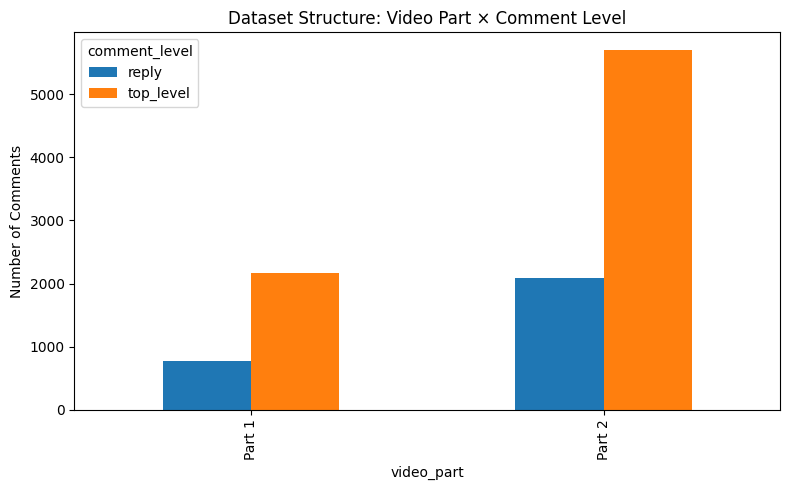

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/01_dataset_structure_20260616_095359.png


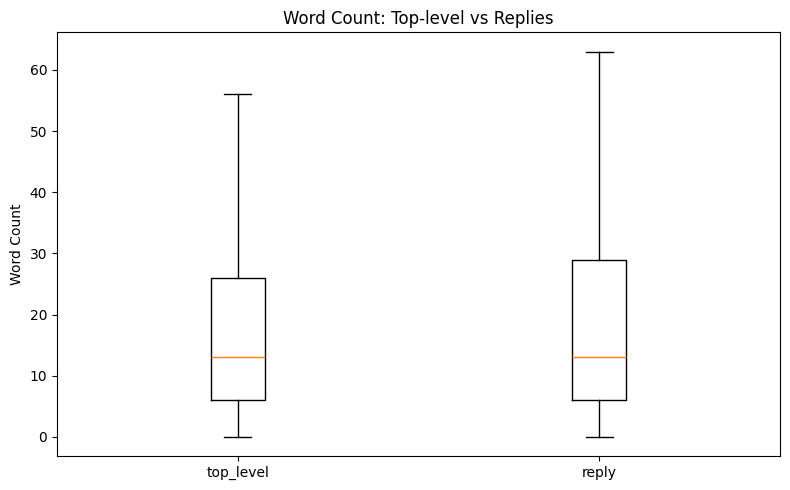

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/02_word_count_level_20260616_095359.png


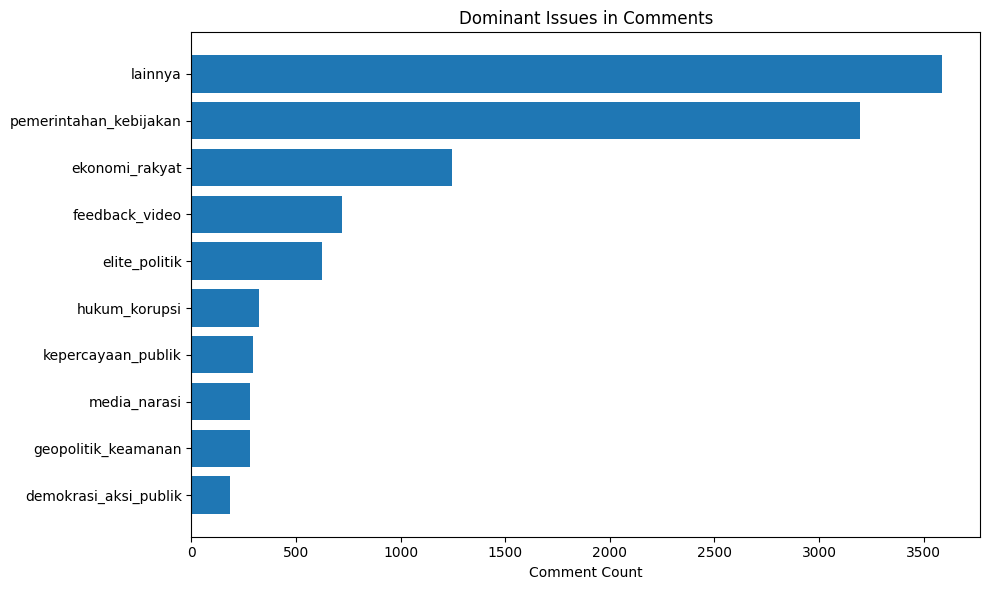

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/03_dominant_issues_20260616_095359.png


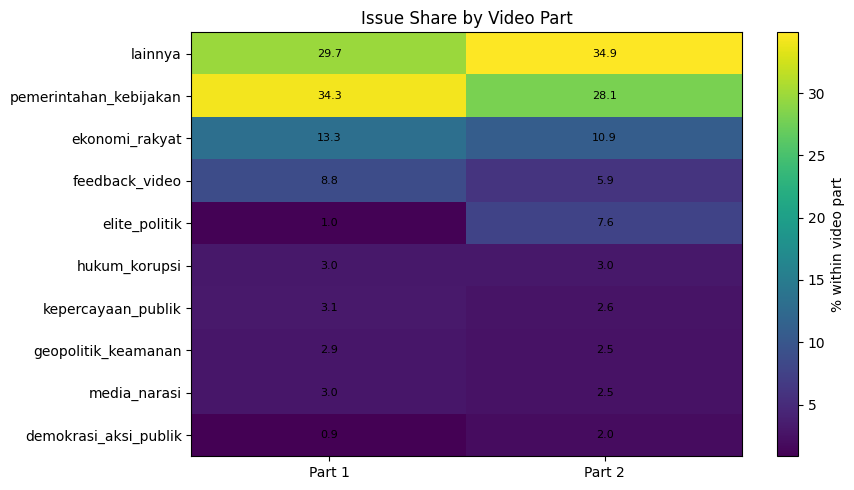

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/04_issue_share_by_part_20260616_095359.png


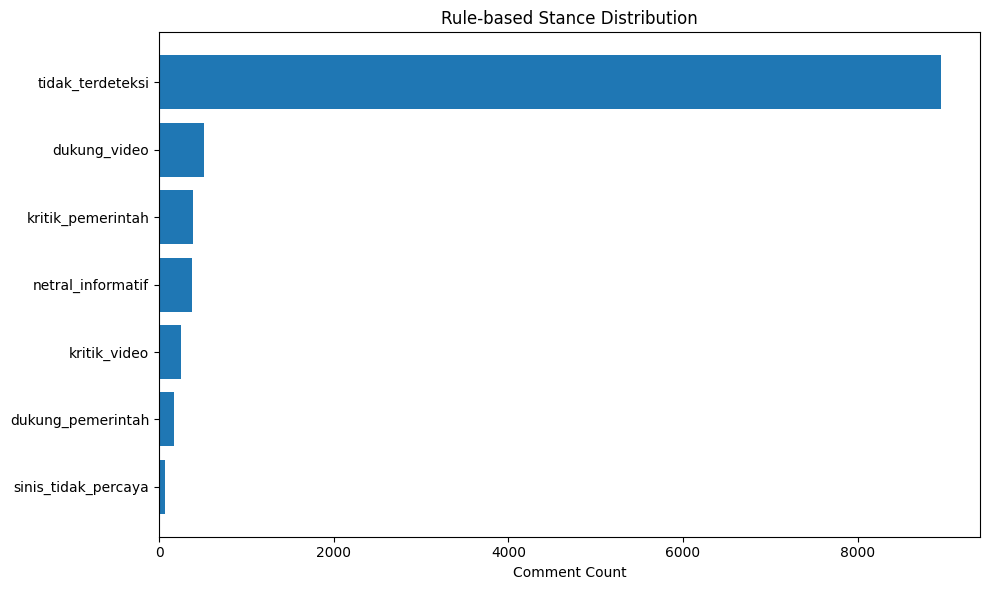

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/05_stance_distribution_20260616_095359.png


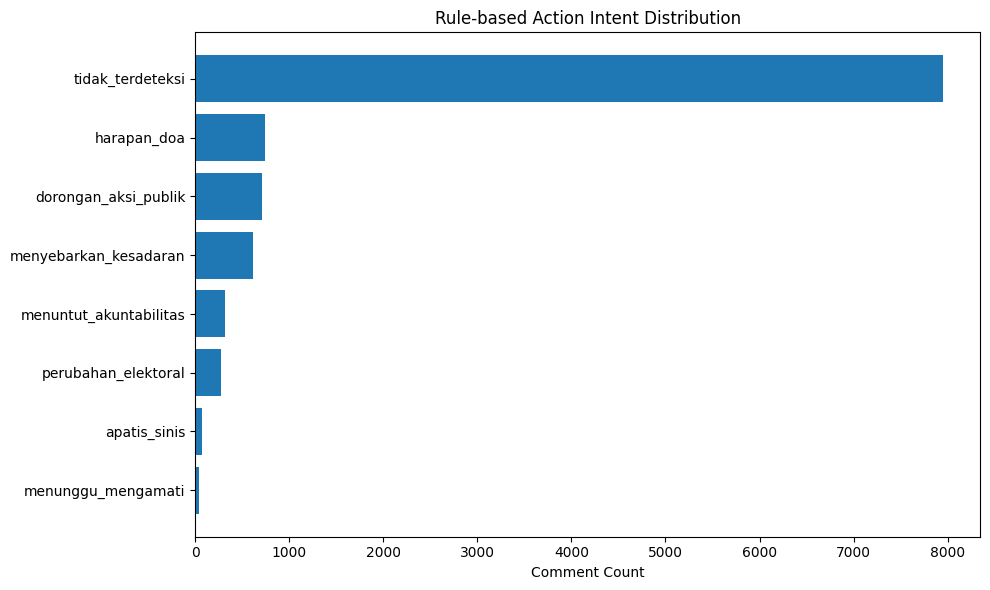

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/06_action_intent_distribution_20260616_095359.png


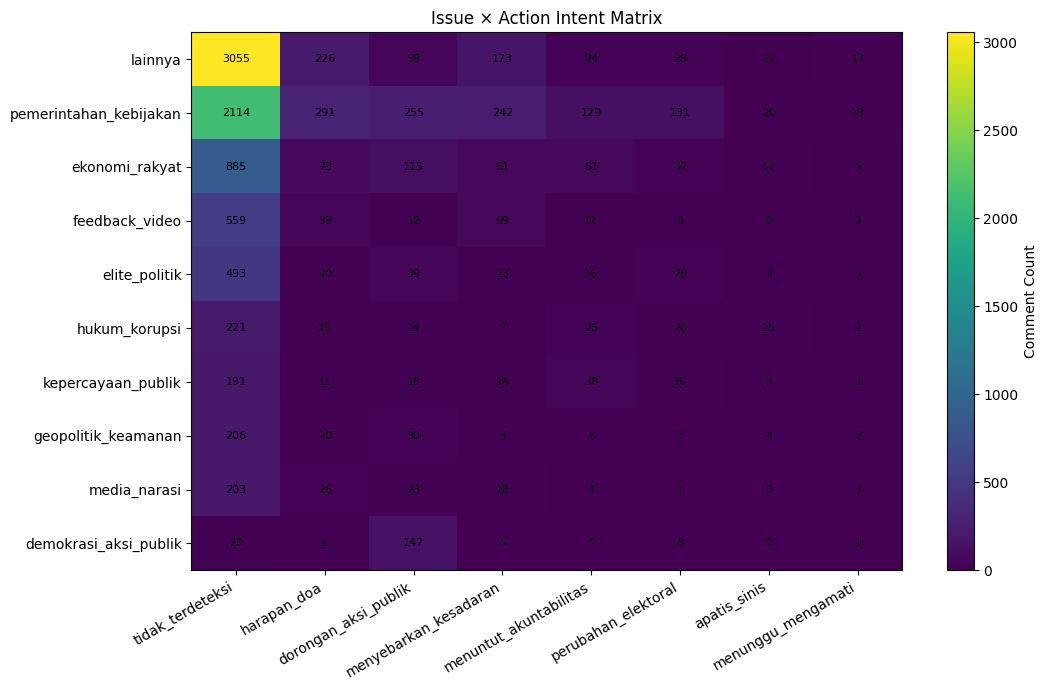

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/07_issue_action_matrix_20260616_095359.png


PosixPath('/content/drive/MyDrive/sentimenuntoldstory/outputs/figures/07_issue_action_matrix_20260616_095359.png')

In [8]:
overview_counts = pd.crosstab(df["video_part"], df["comment_level"])
plt.figure(figsize=(8,5))
overview_counts.plot(kind="bar", ax=plt.gca())
plt.title("Dataset Structure: Video Part × Comment Level")
plt.ylabel("Number of Comments")
save_fig("01_dataset_structure")

plt.figure(figsize=(8,5))
plt.boxplot([
    df.loc[df["comment_level"]=="top_level","clean_word_count"].dropna(),
    df.loc[df["comment_level"]=="reply","clean_word_count"].dropna()
], labels=["top_level","reply"], showfliers=False)
plt.title("Word Count: Top-level vs Replies")
plt.ylabel("Word Count")
save_fig("02_word_count_level")

issue_counts = df["primary_issue"].value_counts().head(12)
plt.figure(figsize=(10,6))
plt.barh(issue_counts.sort_values().index, issue_counts.sort_values().values)
plt.title("Dominant Issues in Comments")
plt.xlabel("Comment Count")
save_fig("03_dominant_issues")

issue_part = pd.crosstab(df["primary_issue"], df["video_part"], normalize="columns") * 100
issue_part = issue_part.loc[issue_counts.index.intersection(issue_part.index)]
plt.figure(figsize=(9, max(5, len(issue_part)*0.4)))
plt.imshow(issue_part.values, aspect="auto")
plt.colorbar(label="% within video part")
plt.xticks(range(issue_part.shape[1]), issue_part.columns)
plt.yticks(range(issue_part.shape[0]), issue_part.index)
plt.title("Issue Share by Video Part")
for i in range(issue_part.shape[0]):
    for j in range(issue_part.shape[1]):
        plt.text(j, i, f"{issue_part.values[i,j]:.1f}", ha="center", va="center", fontsize=8)
save_fig("04_issue_share_by_part")

for col, title, fname in [
    ("stance_label_rule", "Rule-based Stance Distribution", "05_stance_distribution"),
    ("action_intent_rule", "Rule-based Action Intent Distribution", "06_action_intent_distribution")
]:
    counts = df[col].value_counts()
    plt.figure(figsize=(10,6))
    plt.barh(counts.sort_values().index, counts.sort_values().values)
    plt.title(title)
    plt.xlabel("Comment Count")
    save_fig(fname)

issue_action = pd.crosstab(df["primary_issue"], df["action_intent_rule"])
top_issues = df["primary_issue"].value_counts().head(10).index
top_actions = df["action_intent_rule"].value_counts().head(8).index
view = issue_action.loc[top_issues, top_actions]
plt.figure(figsize=(11,7))
plt.imshow(view.values, aspect="auto")
plt.colorbar(label="Comment Count")
plt.xticks(range(view.shape[1]), view.columns, rotation=30, ha="right")
plt.yticks(range(view.shape[0]), view.index)
plt.title("Issue × Action Intent Matrix")
for i in range(view.shape[0]):
    for j in range(view.shape[1]):
        plt.text(j, i, int(view.values[i,j]), ha="center", va="center", fontsize=8)
save_fig("07_issue_action_matrix")

In [9]:
RUN_BERT_INFERENCE = True
BERT_MODEL_NAME = "w11wo/indonesian-roberta-base-sentiment-classifier"
BERT_FALLBACK_MODEL_NAME = "mdhugol/indonesia-bert-sentiment-classification"
BERT_BATCH_SIZE = 32
BERT_MAX_LENGTH = 192

bert_cache_path = TABLES_DIR / "bert_sentiment_predictions_latest.csv"

if bert_cache_path.exists():
    bert_cache = pd.read_csv(bert_cache_path)
    df = df.merge(bert_cache[["comment_id","bert_sentiment","bert_confidence"]], on="comment_id", how="left")
    print("Loaded BERT cache:", bert_cache_path)
elif RUN_BERT_INFERENCE:
    import torch
    from transformers import pipeline
    device = 0 if torch.cuda.is_available() else -1
    print("Device:", "GPU" if device == 0 else "CPU")
    try:
        clf = pipeline("sentiment-analysis", model=BERT_MODEL_NAME, tokenizer=BERT_MODEL_NAME, device=device, truncation=True, max_length=BERT_MAX_LENGTH)
        used_model = BERT_MODEL_NAME
    except Exception as e:
        print("Primary model failed, fallback:", repr(e))
        clf = pipeline("sentiment-analysis", model=BERT_FALLBACK_MODEL_NAME, tokenizer=BERT_FALLBACK_MODEL_NAME, device=device, truncation=True, max_length=BERT_MAX_LENGTH)
        used_model = BERT_FALLBACK_MODEL_NAME

    infer_df = df[df["clean_text_model"].astype(str).str.strip() != ""].copy()
    texts = infer_df["clean_text_model"].astype(str).tolist()
    pred_labels, pred_scores = [], []
    for start in range(0, len(texts), BERT_BATCH_SIZE):
        outputs = clf(texts[start:start+BERT_BATCH_SIZE])
        for out in outputs:
            label = str(out.get("label","")).lower()
            score = float(out.get("score", np.nan))
            if "pos" in label or label in ["label_2","2"]:
                norm = "positive"
            elif "neg" in label or label in ["label_0","0"]:
                norm = "negative"
            elif "neu" in label or label in ["label_1","1"]:
                norm = "neutral"
            else:
                norm = label
            pred_labels.append(norm)
            pred_scores.append(score)

    df["bert_sentiment"] = pd.Series([None] * len(df), dtype="object")
    df["bert_confidence"] = pd.Series(np.nan, dtype="float64")
    df.loc[infer_df.index, "bert_sentiment"] = pd.Series(pred_labels, index=infer_df.index, dtype="object")
    df.loc[infer_df.index, "bert_confidence"] = pd.Series(pred_scores, index=infer_df.index, dtype="float64")
    df[["comment_id","bert_sentiment","bert_confidence"]].to_csv(bert_cache_path, index=False)
    print("Saved BERT cache:", bert_cache_path)
else:
    print("BERT inference disabled and cache not found.")

if "bert_sentiment" in df.columns:
    display(df[["comment_text","bert_sentiment","bert_confidence"]].head())

Device: GPU


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Saved BERT cache: /content/drive/MyDrive/sentimenuntoldstory/outputs/tables/bert_sentiment_predictions_latest.csv


,comment_text,bert_sentiment,bert_confidence
0,Di tengah situasi ekonomi dan geopolitik yang ...,positive,0.743560
1,Mbg buat suapin mulut yang lain juga pak,negative,0.955240
2,GK ada program yg TDK di . ...,negative,0.658688
3,"Bukan dibully, dia itu memang penghianat dari ...",negative,0.893839
4,"Nice Om, Videonya sangat tepat. Cara berfikir ...",positive,0.877071


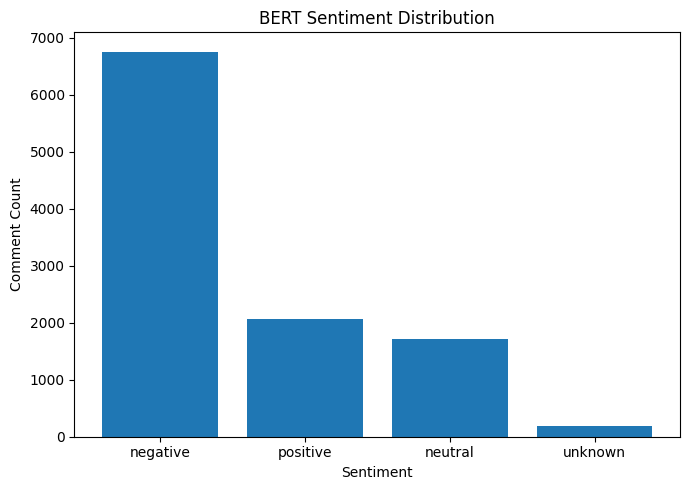

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/08_sentiment_distribution_20260616_095359.png


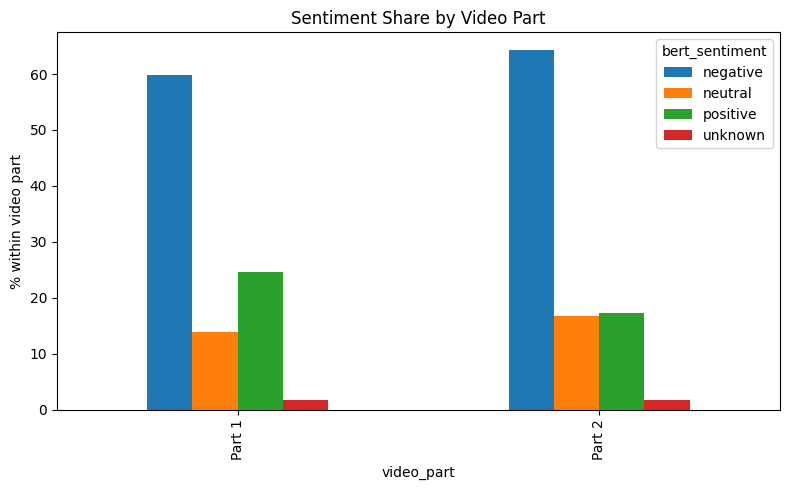

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/09_sentiment_by_part_20260616_095359.png


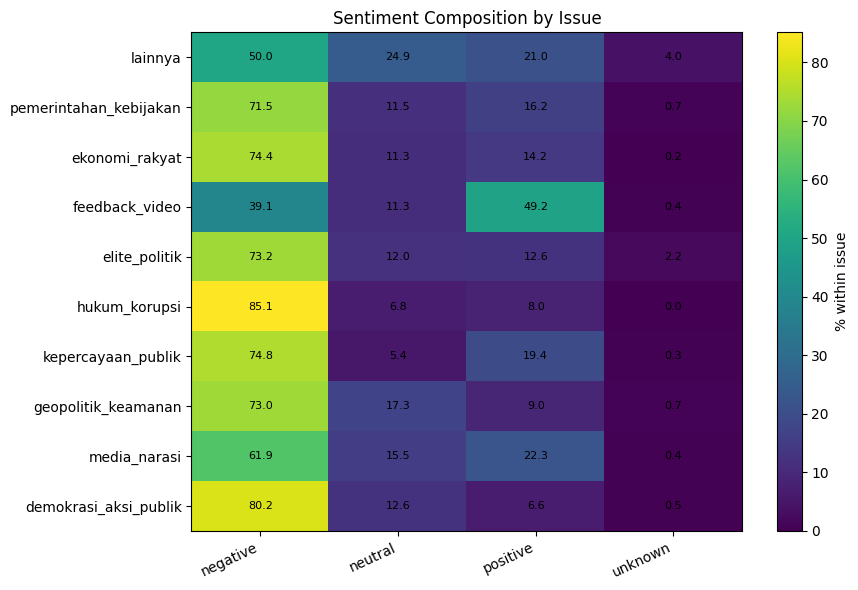

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/10_sentiment_by_issue_20260616_095359.png


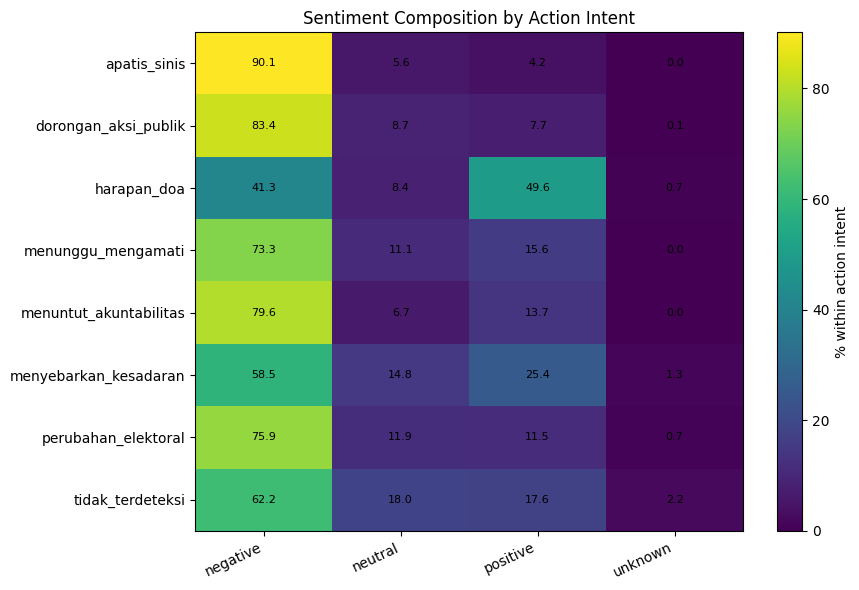

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/11_sentiment_by_action_20260616_095359.png


In [10]:
if "bert_sentiment" in df.columns:
    counts = df["bert_sentiment"].fillna("unknown").value_counts()
    plt.figure(figsize=(7,5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("BERT Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Comment Count")
    save_fig("08_sentiment_distribution")

    sent_part = pd.crosstab(df["bert_sentiment"].fillna("unknown"), df["video_part"], normalize="columns") * 100
    plt.figure(figsize=(8,5))
    sent_part.T.plot(kind="bar", ax=plt.gca())
    plt.title("Sentiment Share by Video Part")
    plt.ylabel("% within video part")
    save_fig("09_sentiment_by_part")

    sent_issue = pd.crosstab(df["primary_issue"], df["bert_sentiment"].fillna("unknown"), normalize="index") * 100
    top_issues = df["primary_issue"].value_counts().head(10).index
    sent_issue = sent_issue.loc[top_issues]
    plt.figure(figsize=(9,6))
    plt.imshow(sent_issue.values, aspect="auto")
    plt.colorbar(label="% within issue")
    plt.xticks(range(sent_issue.shape[1]), sent_issue.columns, rotation=25, ha="right")
    plt.yticks(range(sent_issue.shape[0]), sent_issue.index)
    plt.title("Sentiment Composition by Issue")
    for i in range(sent_issue.shape[0]):
        for j in range(sent_issue.shape[1]):
            plt.text(j, i, f"{sent_issue.values[i,j]:.1f}", ha="center", va="center", fontsize=8)
    save_fig("10_sentiment_by_issue")

    sent_action = pd.crosstab(df["action_intent_rule"], df["bert_sentiment"].fillna("unknown"), normalize="index") * 100
    plt.figure(figsize=(9,6))
    plt.imshow(sent_action.values, aspect="auto")
    plt.colorbar(label="% within action intent")
    plt.xticks(range(sent_action.shape[1]), sent_action.columns, rotation=25, ha="right")
    plt.yticks(range(sent_action.shape[0]), sent_action.index)
    plt.title("Sentiment Composition by Action Intent")
    for i in range(sent_action.shape[0]):
        for j in range(sent_action.shape[1]):
            plt.text(j, i, f"{sent_action.values[i,j]:.1f}", ha="center", va="center", fontsize=8)
    save_fig("11_sentiment_by_action")
else:
    print("No bert_sentiment column.")

,topic_id,top_terms,size
0,0,"yang, tidak, itu, dan, di, ada, dari, jadi, bi...",3604
4,4,"ini, video, video ini, saya, nonton, harus, di...",1254
3,3,"kita, bersatu, negara, mari, harus, mari kita,...",1200
6,6,"indonesia, rakyat, rakyat indonesia, dan, semo...",873
9,9,"singapura, singapore, di, ke, amerika, aja, se...",761
5,5,"prabowo, pak prabowo, pak, sehat, selalu, pres...",649
1,1,"pak gema, pak, gema, terimakasih, keren, terim...",507
2,2,"prof, prof gema, gema, sehat, selalu, sehat se...",446
8,8,"antek, asing, antek asing, antek antek, asing ...",335
7,7,"terima, terima kasih, kasih, kasih pak, kasih ...",185


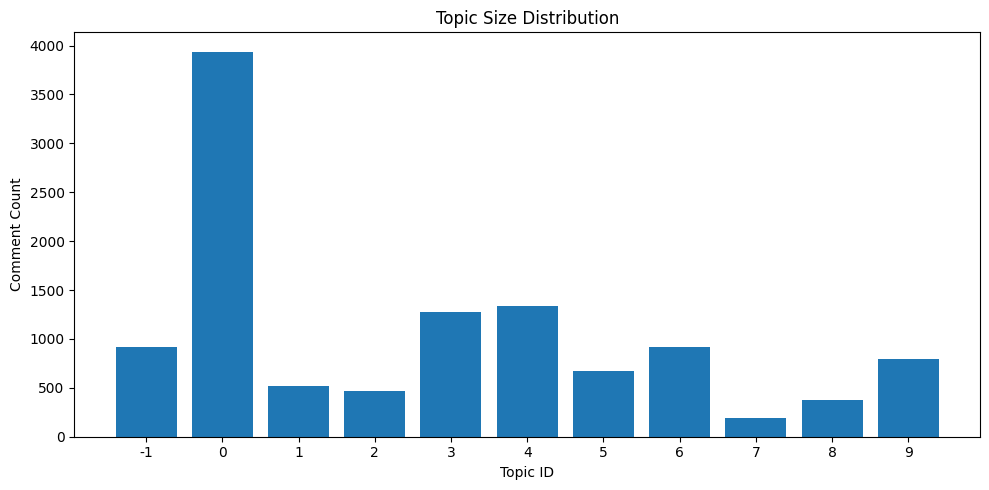

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/12_topic_size_distribution_20260616_095359.png


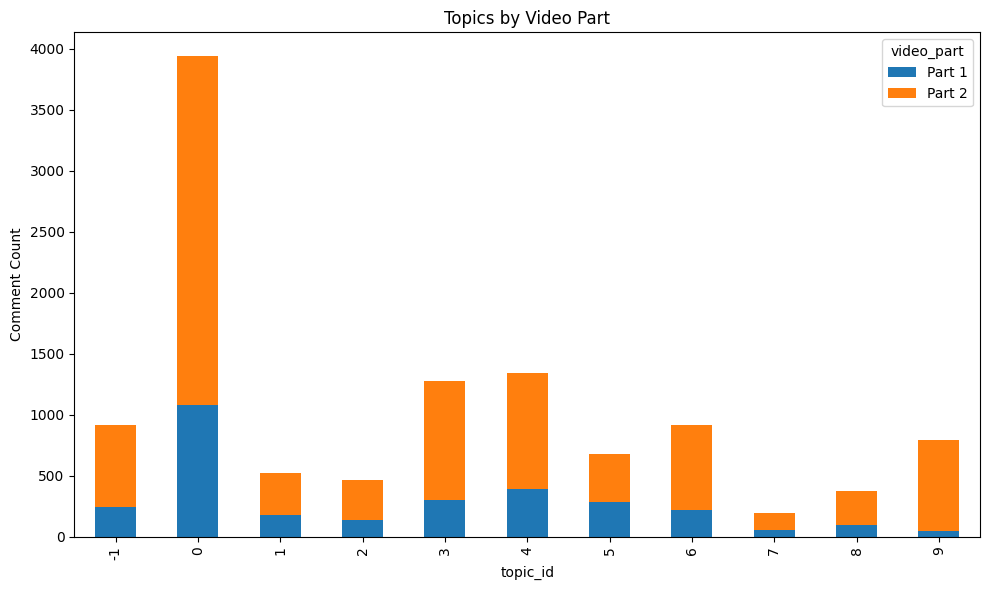

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/13_topics_by_part_20260616_095359.png


PosixPath('/content/drive/MyDrive/sentimenuntoldstory/outputs/figures/13_topics_by_part_20260616_095359.png')

In [11]:
N_TOPICS = 10
topic_df = df[df["clean_text_model"].astype(str).str.split().str.len() >= 3].copy()
docs = topic_df["clean_text_model"].astype(str).tolist()

vectorizer = TfidfVectorizer(max_features=20000, min_df=5, max_df=0.90, ngram_range=(1,2), sublinear_tf=True)
X = vectorizer.fit_transform(docs)

nmf = NMF(n_components=N_TOPICS, random_state=SEED, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X)
H = nmf.components_
topic_ids = W.argmax(axis=1)
topic_df["topic_id"] = topic_ids

features = np.array(vectorizer.get_feature_names_out())
rows = []
for topic_idx, weights in enumerate(H):
    top_idx = weights.argsort()[::-1][:12]
    rows.append({
        "topic_id": int(topic_idx),
        "top_terms": ", ".join(features[top_idx]),
        "size": int((topic_ids == topic_idx).sum())
    })
topic_info = pd.DataFrame(rows).sort_values("size", ascending=False)
topic_info_path = TABLES_DIR / f"nmf_topic_info_{RUN_ID}.csv"
topic_info.to_csv(topic_info_path, index=False)
display(topic_info)

df = df.merge(topic_df[["comment_id","topic_id"]], on="comment_id", how="left")

topic_counts = df["topic_id"].fillna(-1).astype(int).value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title("Topic Size Distribution")
plt.xlabel("Topic ID")
plt.ylabel("Comment Count")
save_fig("12_topic_size_distribution")

topic_part = pd.crosstab(df["topic_id"].fillna(-1).astype(int), df["video_part"])
plt.figure(figsize=(10,6))
topic_part.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Topics by Video Part")
plt.ylabel("Comment Count")
save_fig("13_topics_by_part")

In [12]:
def top_examples(dataframe, label_col, label_value, n=5):
    sub = dataframe[dataframe[label_col].astype(str) == str(label_value)].copy()
    sub = sub.sort_values("like_count", ascending=False)
    examples = []
    for _, row in sub.head(n).iterrows():
        examples.append({
            "comment_id": str(row.get("comment_id","")),
            "video_part": str(row.get("video_part","")),
            "comment_level": str(row.get("comment_level","")),
            "like_count": int(row.get("like_count",0)),
            "text_excerpt": str(row.get("comment_text",""))[:280]
        })
    return examples

dashboard_summary = {
    "run_id": RUN_ID,
    "total_comments": int(len(df)),
    "video_part_counts": to_count_dict(df["video_part"]),
    "comment_level_counts": to_count_dict(df["comment_level"]),
    "sentiment_percent": to_percent_dict(df["bert_sentiment"]) if "bert_sentiment" in df.columns else {},
    "issue_counts_top": to_count_dict(df["primary_issue"], top_n=12),
    "stance_counts": to_count_dict(df["stance_label_rule"]),
    "action_intent_counts": to_count_dict(df["action_intent_rule"]),
    "topic_summary": topic_info.to_dict(orient="records") if "topic_info" in globals() else [],
    "top_negative_examples": top_examples(df, "bert_sentiment", "negative", 8) if "bert_sentiment" in df.columns else [],
    "top_issue_examples": {issue: top_examples(df, "primary_issue", issue, 3) for issue in df["primary_issue"].value_counts().head(5).index},
    "method_note": "Sentiment uses BERT or cached predictions. Issue/stance/action are rule-based weak-supervision outputs and need manual validation."
}
save_json(dashboard_summary, REPORTS_DIR / "dashboard_summary_latest.json")
save_json(dashboard_summary, REPORTS_DIR / f"dashboard_summary_{RUN_ID}.json")
display(pd.DataFrame(dashboard_summary["issue_counts_top"].items(), columns=["issue","count"]))

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/reports/dashboard_summary_latest.json
Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/reports/dashboard_summary_20260616_095359.json


,issue,count
0,lainnya,3590
1,pemerintahan_kebijakan,3285
2,ekonomi_rakyat,1378
3,elite_politik,1050
4,feedback_video,726
5,hukum_korupsi,329
6,kepercayaan_publik,300
7,geopolitik_keamanan,286
8,media_narasi,278
9,demokrasi_aksi_publik,184


In [13]:
LABELING_SAMPLE_SIZE = min(1200, len(df))
label_df = df.copy()
label_df["sampling_priority"] = 0.0

if "bert_confidence" in label_df.columns:
    label_df["bert_confidence"] = pd.to_numeric(label_df["bert_confidence"], errors="coerce")
    label_df["uncertainty"] = 1 - label_df["bert_confidence"].fillna(0.5)
    label_df["sampling_priority"] += label_df["uncertainty"]
else:
    label_df["uncertainty"] = np.nan

label_df["sampling_priority"] += np.log1p(label_df["like_count"]) * 0.05
label_df["sampling_priority"] += label_df["is_reply"].astype(int) * 0.10
label_df["sampling_priority"] += (label_df["primary_issue"] == "lainnya").astype(int) * 0.15

top_priority = label_df.sort_values("sampling_priority", ascending=False).head(int(LABELING_SAMPLE_SIZE * 0.60))
remaining = label_df.drop(index=top_priority.index)
random_part = remaining.sample(n=max(0, LABELING_SAMPLE_SIZE - len(top_priority)), random_state=SEED) if len(remaining) > 0 else remaining
queue = pd.concat([top_priority, random_part], axis=0).drop_duplicates("comment_id")

cols = ["comment_id","video_part","comment_level","parent_id","comment_text","clean_text_model","context_text_model","like_count","reply_count","bert_sentiment","bert_confidence","primary_issue","stance_label_rule","action_intent_rule","topic_id"]
for c in cols:
    if c not in queue.columns:
        queue[c] = ""
queue = queue[cols].copy()
queue["sentiment_label"] = ""
queue["issue_label"] = ""
queue["stance_label"] = ""
queue["action_intent_label"] = ""
queue["label_notes"] = ""

queue_path = TABLES_DIR / "manual_labeling_queue_latest.csv"
queue.to_csv(queue_path, index=False)
print("Saved labeling queue:", queue_path)
display(queue.head())

Saved labeling queue: /content/drive/MyDrive/sentimenuntoldstory/outputs/tables/manual_labeling_queue_latest.csv


,comment_id,video_part,comment_level,parent_id,comment_text,clean_text_model,context_text_model,like_count,reply_count,bert_sentiment,bert_confidence,primary_issue,stance_label_rule,action_intent_rule,topic_id,sentiment_label,issue_label,stance_label,action_intent_label,label_notes
11240,UgxhVPFFyVSwVIS_OXJ4AaABAg.AXnA7CrnNCSAXnDV4eroG-,Part 2,reply,UgxhVPFFyVSwVIS_OXJ4AaABAg,Sudh dapat bitcoin kaya dia,sudh dapat bitcoin kaya dia,parent_context ferry irwandi mana ngerti indon...,2,0,neutral,0.399456,lainnya,tidak_terdeteksi,tidak_terdeteksi,0.0,,,,,
11057,Ugz2Rdbui_Y_y3AF2el4AaABAg.AXnCoF5a70tAXo_OSlVU2E,Part 2,reply,Ugz2Rdbui_Y_y3AF2el4AaABAg,​@yosepyonatan5818jawaban 2 dr 10 tong,2 dari 10 tong,parent_context tolong disiarkan di tv nasional...,0,0,positive,0.352707,lainnya,tidak_terdeteksi,tidak_terdeteksi,0.0,,,,,
10730,UgxfapUx0pa4hk7_usl4AaABAg.AXnEhGPLFQiAXnUoSqLIMT,Part 2,reply,UgxfapUx0pa4hk7_usl4AaABAg,TV nasional yang penting duit,tv nasional yang penting duit,parent_context yang seperti gini yang harus di...,11,0,negative,0.486444,lainnya,tidak_terdeteksi,tidak_terdeteksi,4.0,,,,,
11295,UgwMUWd2NONy5p08gwJ4AaABAg.AXn9EeHUJlTAXnADtID8qU,Part 2,reply,UgwMUWd2NONy5p08gwJ4AaABAg,​@dodyagung9658mungkin dan tak mungkin ada tp ...,dan tidak mungkin ada tp indo perlu jg pemersa...,parent_context kupngn pak gema bang bennix gab...,0,0,positive,0.398273,lainnya,tidak_terdeteksi,tidak_terdeteksi,0.0,,,,,
10954,UgxpRtkDivT9N9VJPrZ4AaABAg,Part 2,top_level,NaN,Yg penting sih DSI jalan biar kering tuh singa...,yang penting sih dsi jalan biar kering tuh sin...,yang penting sih dsi jalan biar kering tuh sin...,3,0,positive,0.369704,lainnya,tidak_terdeteksi,tidak_terdeteksi,9.0,,,,,


Using pseudo-labels with confidence >= 0.70


,count
sentiment_label,
negative,5641
positive,1519
neutral,1029


Label source: bert_pseudo_label | rows: 8189
Training: 01_word_complement_nb
Training: 02_word_logreg
Training: 03_word_linear_svc
Training: 04_char_logreg
Training: 05_char_linear_svc
Training: 06_word_char_logreg
Training: 07_word_ridge
Training: 08_word_sgd
Training: 09_PROPOSED_text_metadata_logreg


,model_name,train_macro_f1,val_macro_f1,test_macro_f1,gap_train_val,production_score,fit_status,label_source
0,09_PROPOSED_text_metadata_logreg,0.810703,0.689791,0.718736,0.120912,0.629335,reasonable_fit,bert_pseudo_label
1,05_char_linear_svc,0.898065,0.718893,0.746257,0.179172,0.629308,reasonable_fit,bert_pseudo_label
2,04_char_logreg,0.754600,0.669545,0.711666,0.085055,0.627018,reasonable_fit,bert_pseudo_label
3,06_word_char_logreg,0.812132,0.682729,0.718294,0.129403,0.618027,reasonable_fit,bert_pseudo_label
4,02_word_logreg,0.807397,0.678427,0.709832,0.128970,0.613943,reasonable_fit,bert_pseudo_label
5,07_word_ridge,0.903534,0.688819,0.723723,0.214715,0.581461,overfitting_warning,bert_pseudo_label
6,03_word_linear_svc,0.946839,0.701228,0.724590,0.245610,0.578423,overfitting_warning,bert_pseudo_label
7,08_word_sgd,0.913755,0.689853,0.715049,0.223903,0.577901,overfitting_warning,bert_pseudo_label
8,01_word_complement_nb,0.797684,0.625801,0.635826,0.171884,0.539859,reasonable_fit,bert_pseudo_label


Best model: 09_PROPOSED_text_metadata_logreg
Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/models/BEST_MODEL_LATEST.joblib


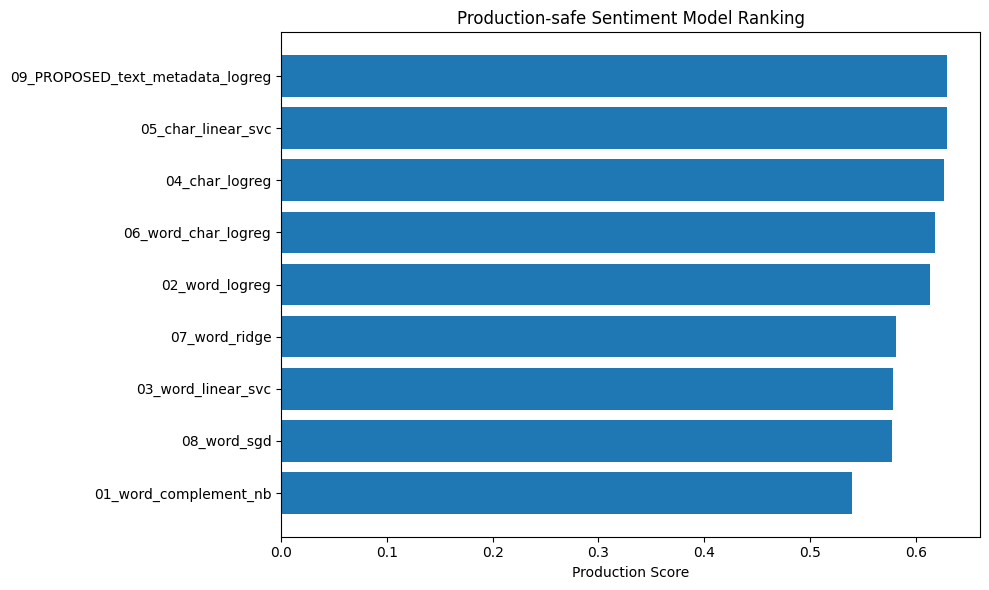

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/14_sentiment_model_ranking_20260616_095359.png


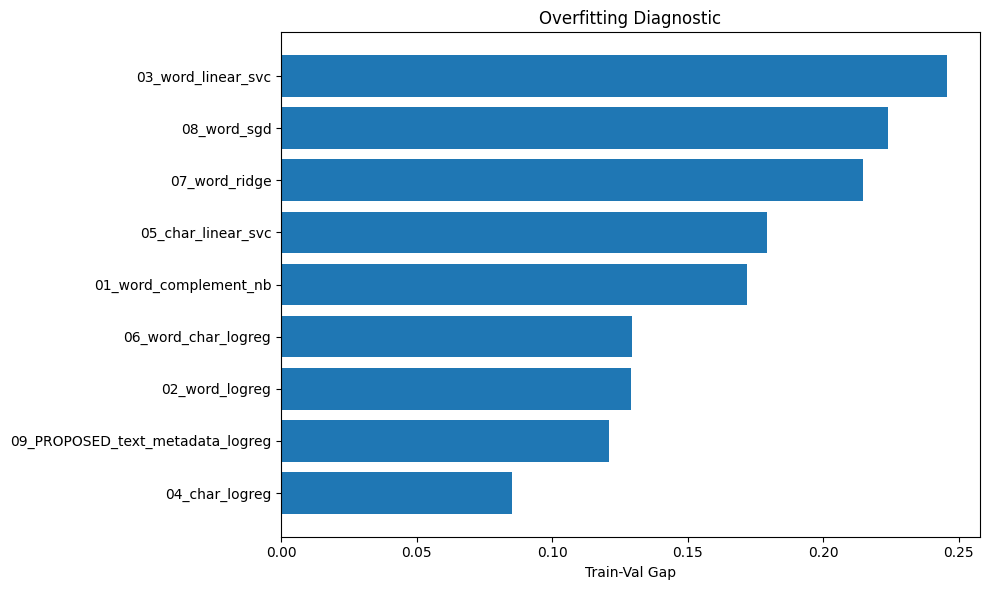

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/15_sentiment_model_gap_20260616_095359.png


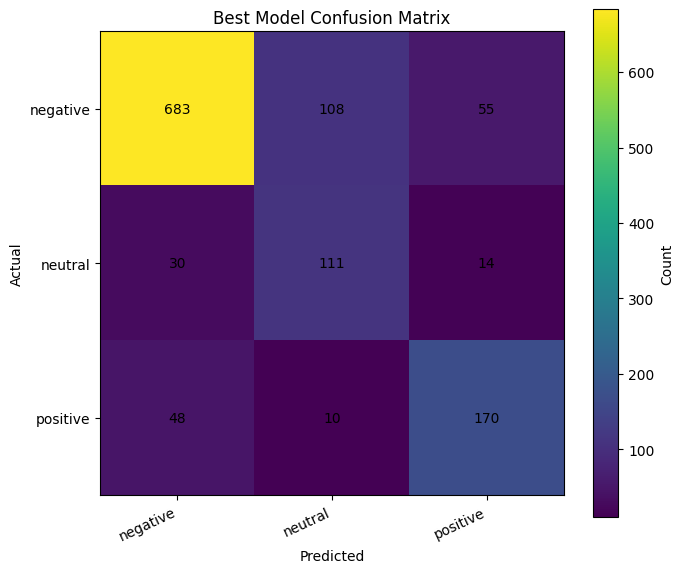

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/figures/16_best_model_confusion_matrix_20260616_095359.png
Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/reports/BEST_MODEL_LIGHTWEIGHT_METADATA_LATEST.json


In [14]:
RUN_SUPERVISED_BENCHMARK = True
TARGET_LABEL_COLUMN = "sentiment_label"

def find_labeled_file():
    for p in [RAW_DIR/"labeled_comments.csv", DRIVE_ROOT/"labeled_comments.csv", TABLES_DIR/"labeled_comments.csv", OUTPUT_DIR/"labeled_comments.csv"]:
        if p.exists():
            return p
    return None

if RUN_SUPERVISED_BENCHMARK:
    labeled_file = find_labeled_file()
    if labeled_file is not None:
        supervised_df = pd.read_csv(labeled_file)
        label_source = "manual_label"
        if TARGET_LABEL_COLUMN not in supervised_df.columns:
            raise ValueError(f"labeled_comments.csv must contain {TARGET_LABEL_COLUMN}")
        if "context_text_model" not in supervised_df.columns:
            supervised_df["context_text_model"] = supervised_df.get("clean_text_model", supervised_df.get("comment_text", "")).astype(str).apply(normalize_text)
    else:
        if "bert_sentiment" not in df.columns:
            raise RuntimeError("No labeled_comments.csv and no bert_sentiment. Run BERT inference first.")
        supervised_df = df.copy()
        supervised_df[TARGET_LABEL_COLUMN] = supervised_df["bert_sentiment"].astype("string")
        label_source = "bert_pseudo_label"
        if "bert_confidence" in supervised_df.columns:
            supervised_df["bert_confidence"] = pd.to_numeric(supervised_df["bert_confidence"], errors="coerce")
            filtered = supervised_df[(supervised_df["bert_confidence"].isna()) | (supervised_df["bert_confidence"] >= 0.70)].copy()
            if len(filtered) >= 500:
                supervised_df = filtered
                print("Using pseudo-labels with confidence >= 0.70")

    valid = {"positive","negative","neutral"}
    supervised_df["context_text_model"] = supervised_df["context_text_model"].astype("string").fillna("").str.strip()
    supervised_df[TARGET_LABEL_COLUMN] = supervised_df[TARGET_LABEL_COLUMN].astype("string").str.lower().str.strip()
    supervised_df = supervised_df[(supervised_df["context_text_model"]!="") & (supervised_df[TARGET_LABEL_COLUMN].isin(valid))].copy()
    supervised_df = supervised_df.drop_duplicates("context_text_model")
    supervised_df["train_word_count"] = supervised_df["context_text_model"].astype(str).str.split().str.len()
    supervised_df = supervised_df[supervised_df["train_word_count"] >= 3].copy()

    display(supervised_df[TARGET_LABEL_COLUMN].value_counts().to_frame("count"))
    print("Label source:", label_source, "| rows:", len(supervised_df))

    for col, default in {"like_count":0, "reply_count":0, "is_reply":False}.items():
        if col not in supervised_df.columns:
            supervised_df[col] = default
    supervised_df["like_count"] = pd.to_numeric(supervised_df["like_count"], errors="coerce").fillna(0)
    supervised_df["reply_count"] = pd.to_numeric(supervised_df["reply_count"], errors="coerce").fillna(0)
    supervised_df["is_reply_numeric"] = supervised_df["is_reply"].astype(str).str.lower().isin(["true","1","yes","reply"]).astype(int)

    X_full = supervised_df[["context_text_model","like_count","reply_count","is_reply_numeric"]].copy()
    X_text = supervised_df["context_text_model"].astype(str)
    y = supervised_df[TARGET_LABEL_COLUMN].astype(str)

    X_train_full, X_temp_full, y_train, y_temp = train_test_split(X_full, y, test_size=0.30, random_state=SEED, stratify=y)
    X_val_full, X_test_full, y_val, y_test = train_test_split(X_temp_full, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)
    X_train_text, X_val_text, X_test_text = X_train_full["context_text_model"].astype(str), X_val_full["context_text_model"].astype(str), X_test_full["context_text_model"].astype(str)

    candidates = {
        "01_word_complement_nb": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=30000, sublinear_tf=True)), ("clf", ComplementNB())])),
        "02_word_logreg": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=30000, sublinear_tf=True)), ("clf", LogisticRegression(C=0.3, max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=SEED))])),
        "03_word_linear_svc": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=30000, sublinear_tf=True)), ("clf", LinearSVC(C=0.3, class_weight="balanced", random_state=SEED))])),
        "04_char_logreg": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=5, max_df=0.90, max_features=25000, sublinear_tf=True)), ("clf", LogisticRegression(C=0.2, max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=SEED))])),
        "05_char_linear_svc": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=5, max_df=0.90, max_features=25000, sublinear_tf=True)), ("clf", LinearSVC(C=0.2, class_weight="balanced", random_state=SEED))])),
        "06_word_char_logreg": ("text", Pipeline([("features", FeatureUnion([("word", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=25000, sublinear_tf=True)), ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=5, max_df=0.90, max_features=25000, sublinear_tf=True))])), ("clf", LogisticRegression(C=0.2, max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=SEED))])),
        "07_word_ridge": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=30000, sublinear_tf=True)), ("clf", RidgeClassifier(alpha=2.0, class_weight="balanced", random_state=SEED))])),
        "08_word_sgd": ("text", Pipeline([("tfidf", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=30000, sublinear_tf=True)), ("clf", SGDClassifier(loss="log_loss", alpha=1e-4, class_weight="balanced", max_iter=2000, random_state=SEED))])),
    }

    preprocessor = ColumnTransformer([
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=3, max_df=0.90, max_features=25000, sublinear_tf=True), "context_text_model"),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5), min_df=5, max_df=0.90, max_features=25000, sublinear_tf=True), "context_text_model"),
        ("meta", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), ["like_count","reply_count","is_reply_numeric"])
    ])
    candidates["09_PROPOSED_text_metadata_logreg"] = ("full", Pipeline([("preprocess", preprocessor), ("clf", LogisticRegression(C=0.2, max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=SEED))]))

    trained_models, test_predictions, rows = {}, {}, []
    for name, (mode, model) in candidates.items():
        Xtr, Xva, Xte = (X_train_text, X_val_text, X_test_text) if mode == "text" else (X_train_full, X_val_full, X_test_full)
        print("Training:", name)
        model.fit(Xtr, y_train)
        pred_train, pred_val, pred_test = model.predict(Xtr), model.predict(Xva), model.predict(Xte)
        train_f1, val_f1, test_f1 = f1_score(y_train, pred_train, average="macro"), f1_score(y_val, pred_val, average="macro"), f1_score(y_test, pred_test, average="macro")
        gap = train_f1 - val_f1
        production_score = val_f1 - max(gap, 0) * 0.5
        fit_status = "overfitting_warning" if gap >= 0.20 else ("underfitting_warning" if train_f1 < 0.60 and val_f1 < 0.60 else "reasonable_fit")
        rows.append({"model_name":name, "train_macro_f1":train_f1, "val_macro_f1":val_f1, "test_macro_f1":test_f1, "gap_train_val":gap, "production_score":production_score, "fit_status":fit_status, "label_source":label_source})
        trained_models[name] = model
        test_predictions[name] = pred_test

    benchmark_df = pd.DataFrame(rows).sort_values(["production_score","val_macro_f1","test_macro_f1"], ascending=False).reset_index(drop=True)
    display(benchmark_df)
    benchmark_path = TABLES_DIR / f"sentiment_benchmark_v7_{RUN_ID}.csv"
    benchmark_df.to_csv(benchmark_path, index=False)

    best_model_name = benchmark_df.iloc[0]["model_name"]
    production_best_model_name = best_model_name
    best_model = trained_models[best_model_name]
    best_model_latest = MODELS_DIR / "BEST_MODEL_LATEST.joblib"
    best_model_versioned = MODELS_DIR / f"BEST_MODEL_{best_model_name}_{RUN_ID}.joblib"
    joblib.dump(best_model, best_model_latest, compress=3)
    joblib.dump(best_model, best_model_versioned, compress=3)
    print("Best model:", best_model_name)
    print("Saved:", best_model_latest)

    best_pred = test_predictions[best_model_name]
    report_df = pd.DataFrame(classification_report(y_test, best_pred, output_dict=True, zero_division=0)).T
    report_path = TABLES_DIR / f"best_model_report_v7_{RUN_ID}.csv"
    report_df.to_csv(report_path)

    plt.figure(figsize=(10,6))
    plot_df = benchmark_df.sort_values("production_score", ascending=True)
    plt.barh(plot_df["model_name"], plot_df["production_score"])
    plt.title("Production-safe Sentiment Model Ranking")
    plt.xlabel("Production Score")
    save_fig("14_sentiment_model_ranking")

    plt.figure(figsize=(10,6))
    plot_df = benchmark_df.sort_values("gap_train_val", ascending=True)
    plt.barh(plot_df["model_name"], plot_df["gap_train_val"])
    plt.title("Overfitting Diagnostic")
    plt.xlabel("Train-Val Gap")
    save_fig("15_sentiment_model_gap")

    cm = confusion_matrix(y_test, best_pred, labels=sorted(y_test.unique()))
    labels_order = sorted(y_test.unique())
    plt.figure(figsize=(7,6))
    plt.imshow(cm)
    plt.colorbar(label="Count")
    plt.xticks(range(len(labels_order)), labels_order, rotation=25, ha="right")
    plt.yticks(range(len(labels_order)), labels_order)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Best Model Confusion Matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i,j]), ha="center", va="center")
    save_fig("16_best_model_confusion_matrix")

    save_json({
        "run_id": RUN_ID,
        "best_model_name": best_model_name,
        "best_model_latest_path": str(best_model_latest),
        "best_model_versioned_path": str(best_model_versioned),
        "label_source": label_source,
        "selection_metric": "production_score",
        "benchmark_path": str(benchmark_path),
        "classification_report_path": str(report_path),
        "note": "If label_source is bert_pseudo_label, this is prototype, not final scientific validation."
    }, REPORTS_DIR / "BEST_MODEL_LIGHTWEIGHT_METADATA_LATEST.json")

In [15]:
runtime_code = '''
import re, html, json, joblib
import pandas as pd
from pathlib import Path

MODEL_PATH = Path("BEST_MODEL_LATEST.joblib")
TAXONOMY_PATH = Path("taxonomy_config_latest.json")

def normalize_text(text):
    if text is None:
        return ""
    text = html.unescape(str(text)).lower()
    text = re.sub(r"http\\S+|www\\.\\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[@#]\\S+", " ", text)
    text = re.sub(r"[^0-9a-zA-ZÀ-ÿĀ-ž\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

def keyword_score(text, keywords):
    return sum((2 if " " in kw else 1) for kw in keywords if kw in text)

def assign_multilabel(text, taxonomy, min_score=1, max_labels=3):
    scores = {label: keyword_score(text, kws) for label, kws in taxonomy.items()}
    selected = [k for k, v in sorted(scores.items(), key=lambda x: x[1], reverse=True) if v >= min_score]
    return selected[:max_labels] if selected else ["lainnya"]

def assign_single_label(text, taxonomy, default_label="tidak_terdeteksi", min_score=1):
    scores = {label: keyword_score(text, kws) for label, kws in taxonomy.items() if kws}
    if not scores:
        return default_label
    best_label, best_score = max(scores.items(), key=lambda x: x[1])
    return best_label if best_score >= min_score else default_label

class CommentIntelligenceRuntime:
    def __init__(self, model_path=MODEL_PATH, taxonomy_path=TAXONOMY_PATH):
        self.model = joblib.load(model_path)
        with open(taxonomy_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
        self.issue_taxonomy = cfg["issue_taxonomy"]
        self.stance_taxonomy = cfg["stance_taxonomy"]
        self.action_taxonomy = cfg["action_taxonomy"]

    def predict_one(self, text, like_count=0, reply_count=0, is_reply=False):
        clean = normalize_text(text)
        try:
            sentiment = self.model.predict([clean])[0]
        except Exception:
            X = pd.DataFrame([{
                "context_text_model": clean,
                "like_count": like_count,
                "reply_count": reply_count,
                "is_reply_numeric": int(bool(is_reply))
            }])
            sentiment = self.model.predict(X)[0]
        issues = assign_multilabel(clean, self.issue_taxonomy)
        return {
            "clean_text": clean,
            "sentiment": str(sentiment),
            "issues": issues,
            "primary_issue": issues[0],
            "stance": assign_single_label(clean, self.stance_taxonomy),
            "action_intent": assign_single_label(clean, self.action_taxonomy),
            "note": "Sentiment from joblib; issue/stance/action from taxonomy rules."
        }
'''
runtime_path = RUNTIME_DIR / "comment_intelligence_runtime.py"
with open(runtime_path, "w", encoding="utf-8") as f:
    f.write(runtime_code)

shutil.copy2(REPORTS_DIR / "taxonomy_config_latest.json", RUNTIME_DIR / "taxonomy_config_latest.json")
best_model_src = MODELS_DIR / "BEST_MODEL_LATEST.joblib"
if best_model_src.exists():
    shutil.copy2(best_model_src, RUNTIME_DIR / "BEST_MODEL_LATEST.joblib")

with open(RUNTIME_DIR / "requirements_backend.txt", "w", encoding="utf-8") as f:
    f.write("pandas\nnumpy\nscikit-learn\njoblib\n")

print("Runtime files:")
for p in RUNTIME_DIR.glob("*"):
    print(p)

Runtime files:
/content/drive/MyDrive/sentimenuntoldstory/outputs/runtime/comment_intelligence_runtime.py
/content/drive/MyDrive/sentimenuntoldstory/outputs/runtime/taxonomy_config_latest.json
/content/drive/MyDrive/sentimenuntoldstory/outputs/runtime/BEST_MODEL_LATEST.joblib
/content/drive/MyDrive/sentimenuntoldstory/outputs/runtime/requirements_backend.txt


In [16]:
for pattern in ["ALL_ARTIFACTS_*.zip", "model_artifacts_*.zip", "v6_ALL_ARTIFACTS_*.zip", "v6_model_artifacts_*.zip"]:
    for p in ZIPS_DIR.glob(pattern):
        p.unlink(missing_ok=True)
        print("Removed heavy zip:", p)

visual_zip_path = shutil.make_archive(
    base_name=str(ZIPS_DIR / f"visual_artifacts_v7_{RUN_ID}"),
    format="zip",
    root_dir=str(FIGURES_DIR)
)

runtime_zip_path = shutil.make_archive(
    base_name=str(ZIPS_DIR / f"runtime_backend_v7_{RUN_ID}"),
    format="zip",
    root_dir=str(RUNTIME_DIR)
)

export_summary = {
    "run_id": RUN_ID,
    "visual_zip_path": visual_zip_path,
    "runtime_zip_path": runtime_zip_path,
    "best_model_latest_exists": (MODELS_DIR / "BEST_MODEL_LATEST.joblib").exists(),
    "dashboard_summary_path": str(REPORTS_DIR / "dashboard_summary_latest.json"),
    "taxonomy_config_path": str(REPORTS_DIR / "taxonomy_config_latest.json"),
    "note": "Lightweight export only. No full outputs zip."
}
save_json(export_summary, REPORTS_DIR / "export_summary_latest.json")

print("EXPORT DONE")
print("Visual ZIP:", visual_zip_path)
print("Runtime ZIP:", runtime_zip_path)
print("Best model:", MODELS_DIR / "BEST_MODEL_LATEST.joblib")

Saved: /content/drive/MyDrive/sentimenuntoldstory/outputs/reports/export_summary_latest.json
EXPORT DONE
Visual ZIP: /content/drive/MyDrive/sentimenuntoldstory/outputs/zips/visual_artifacts_v7_20260616_095359.zip
Runtime ZIP: /content/drive/MyDrive/sentimenuntoldstory/outputs/zips/runtime_backend_v7_20260616_095359.zip
Best model: /content/drive/MyDrive/sentimenuntoldstory/outputs/models/BEST_MODEL_LATEST.joblib
